# Lab 2:   ATLAS Data Analysis



Reminder:  **Lab 2** needs to be submitted in the `Lab2` folder of your personal `PHYS265-spring26` github repo, with the two `lab2.ipynb` and `lab2.html` files.

Lab days: April 6 and 8, during normal class hours.  Report is due on Sunday April 12, at 11.59pm on github, not ELMS.

Avoiding confusion, enter your name here: Anson Cook

## Introduction
------

Imagine you are a physicist working on the ATLAS (**A** **T**oroidal **L**hc **A**pparatu**S**) experiment at CERN in Geneva. At ATLAS, high energy protons are smashed together, and the byproducts are studied. One of the most important measurements to be made is the mass of the $Z^0$ boson.

After you have done your investigations — which you are guided through below — you will
prepare a short report on your findings for grad students in your research group in the form of this notebook. 

A table of relevant physical constants, from the 2024 edition of the Particle Data Group, is
below. Good luck!



| Quantity | Value |
|----------|-------|
|    Mass of Z Boson ($m_{Z^0}$) | $91.1880 \pm 0.0020$ GeV/$c^2$ |
|    Mass of W Boson ($m_W$) | $80.3692 \pm 0.0133$ GeV/$c^2$ |
|    Mass of Higgs Boson ($m_H$)   | $125.20 \pm 0.11$ GeV/$c^2$ |
|    Mass of Electron ($m_e$)   | $0.51099895000 \pm 0.00000000015$ MeV/$c^2$ |
|    Mass of Muon ($m_\mu$)   | $105.6583755 \pm 0.0000023$ MeV/$c^2$ |
|    Mass of Tau ($m_\tau$)   | $1776.93 \pm 0.09$ MeV/$c^2$ |


At the Large Hadron Collider, at CERN, in Geneva, Switzerland, particle physicists collide beams of protons.
This process breaks the protons open, and more fundamental particles are formed, interact, and decay.
One of the most interesting fundamental particles to come out of proton-proton ($pp$) interactions is the $Z^0$-boson, which is the neutral carrier of the *weak* force, and is therefore responsible, along with the $W^{\pm}$-boson, for facilitating many nuclear interactions in the Universe. The photon, which you are more familiar with, is the carrier of the *electromagnetic force*.

The $Z^0$ is unstable and decays. About 10\% of the time, it decays into a pair of charged leptons. 
This can be an electron ($e$) and and anti-electron (or positron, $e^+$).
It can also be a muon/anti-muon pair, or a tau/anti-tau pair.
Because it can do any of these, we substitute the generic letter $\ell$ for lepton, 
and this interaction is known as $Z^0 \rightarrow \ell \bar{\ell}$, 
where the ``bar" over the $\ell$ indicates an anti-particle.
Because charge cannot be created or destroyed, they must have opposite 
(or no\footnote{It is also possible for the $Z^0$ to decay into two photons, or $Z^0 \rightarrow \gamma \gamma$}) 
charge. And, because matter and energy cannot be created or destroyed, 
if $Z^0$ particles are decaying to produce the leptons, 
then the total energy stored in the two leptons must sum to (at least) the mass of the $Z^0$.
This means that if we can measure the energy of all double-lepton events in the detector, 
we should see an *excess* or a *peak* at the mass of the $Z_0$.





In [1]:
# import things. add more imports as needed
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.optimize import curve_fit
import scipy.stats as st
import pandas # for csv reading

## Part 1: Invariant Mass Distribution
------

In the ATLAS detector (which is one of four main experiments at the LHC), 
it is reasonably straightforward to measure four properties of particles 
that come out of the proton-proton interactions. The first is the total energy $E$. 
The second is the transverse-momentum $p_T$, which describes the momentum 
the particle has in the transverse direction. The third is the pseudorapidity $\eta$, 
which describes the angle the particle makes with respect to the beamline. 
If the particle continues straight along the beamline, then $\eta \rightarrow \infty$, 
while if the particle is deflected out at $90^o$, it has $\eta =0$. 
The fourth is the azimuthal angle $\phi$ about the beam. 
That is, if you are staring down the barrel of the collider, a particle with $\eta, \phi = 0, 0$ 
emerges from the interaction point flying directly to the right. 
Where a particle with $\eta, \phi = 0, \pi/2$ emerges from the top flying straight up.

Together, these values fully define the *four momentum* of the particle: 
$p = (E, p_x, p_y, p_z)$ through the following mathematical relationships, 
where $c$ (the speed of light) is treated in a strange fashion and set equal to 1 
(which you will learn more about when you take a course that covers relativity and discuss "natural units"):

$$
p_x = p_T \cos(\phi), \,\,\,\,\, p_y = p_T \sin(\phi), \,\,\,\, p_z = p_T \sinh(\eta)    \tag{1}
$$


The difference between the three-momentum and the energy is the particle's invariant mass:

$$
M = \sqrt{E^2 - (p_x^2 + p_y^2 + p_z^2)}     \tag{2}
$$

If you have *two* particles, and you would like to know the total momentum of the system, 
you have to sum the four momenta: $p_{tot} = p_1 + p_2$.

In the file `atlas_z_to_ll.csv`, you will find five-thousand real ATLAS data events.
These have been pre-selected from the 
[2020 ATLAS open dataset](https://atlas.cern/Resources/Opendata)
so that the ``final states" only contain the two leptons we are interested in.
The first two columns are the $p_T$ (in GeV) for the two leptons; 
the next two columns are the $\eta$, the next two are $\phi$ (radians), 
and the last two are the energy $E$ (in GeV) 
**Note**: One nifty utility of natural units is that momentum and energy have the same units, which makes doing math with them much easier.


1. Load the data into python.
2. For each lepton pair, using the formulas in eq. (1) and eq. (2), calculate the mass of a hypothetical particle which decayed to produce that pair.
   * Hint: first, calculate the vector components, then calculate the summed four-momenta, then calculate the mass.
4. Make a histogram, with error bars, of your calculated invariant mass. You should approximate this as a Poisson counting experiment, so that the error on the number of events in the bin is equal to the square-root of the number of events in the bin. That is: $\sigma = \sqrt{N}$. Label the axes nicely, with units, etc. To make uniform grading possible, please do the histogram from 80 to 100 GeV with 41 bins. That is: `bins = np.linspace(80,100,41)`.


<ErrorbarContainer object of 3 artists>

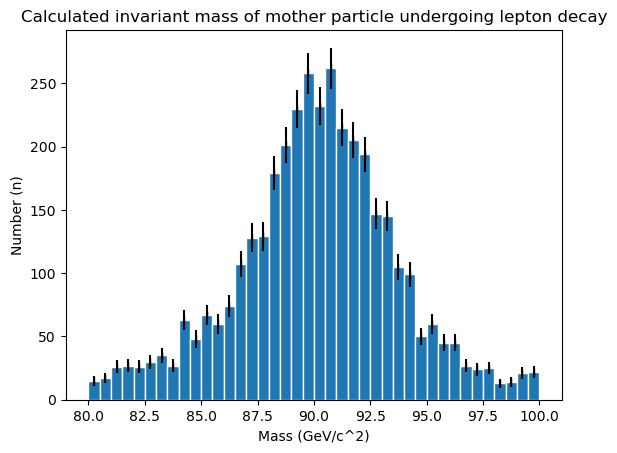

In [2]:
data = pandas.read_csv('atlas_z_to_ll.csv')
# alt. np.loadtxt("title, delimiter, skiprows=n")
# we're just working with one dataset here so i'll name all the columns
pt1 = data["pt1"]
pt2 = data["pt2"]
eta1 = data["eta1"]
eta2 = data["eta2"]
phi1 = data["phi1"]
phi2 = data["phi2"]
E1 = data["E1"]
E2 = data["E2"]

def M(P1, P2, eta1, eta2, phi1, phi2, E1, E2):
    # vector components
    p_x_1 = P1 * np.cos(phi1)
    p_y_1 = P1 * np.sin(phi1)
    p_z_1 = P1 * np.sinh(eta1)
    p_x_2 = P2 * np.cos(phi2)
    p_y_2 = P2 * np.sin(phi2)
    p_z_2 = P2 * np.sinh(eta2)
    p_x = p_x_1 + p_x_2
    p_y = p_y_1 + p_y_2
    p_z = p_z_1 + p_z_2
    
    E_total = E1 + E2

    return np.sqrt((E_total**2) - (p_x**2 + p_y**2 + p_z**2))

fig, ax = plt.subplots()
ax.set_title("Calculated invariant mass of mother particle undergoing lepton decay")
ax.set_ylabel("Number (n)")
ax.set_xlabel("Mass (GeV/c^2)")
linspace = np.linspace(80, 100, 41)
ax.hist(M(pt1, pt2, eta1, eta2, phi1, phi2, E1, E2), bins=linspace, edgecolor='white')

numbers, edges = np.histogram(M(pt1, pt2, eta1, eta2, phi1, phi2, E1, E2), bins=linspace) # there's probably a more efficient way to do this
errors = np.sqrt(numbers)
centers = (edges[:-1] + edges[1:]) / 2
ax.errorbar(centers, numbers, yerr=errors, color='black', fmt='|') # can't use linspace as first argument since there's 41 instead of 40

### Part 2: Breit-Wigner Fit
------

You can show, using scattering theory, that the distribution of decays $\mathcal{D}$ at a reconstructed mass $m$ follows what is known as a Breit-Wigner (to a mathematician, Cauchy-Lorentz) peak. The distribution depends on true rest-mass of the $Z^0$, $m_0$, and on a "width" parameter $\Gamma$:

$$
\mathcal{D}(m; m_0, \Gamma) = \frac{1}{\pi} \frac{\Gamma/2}{(m-m_0)^2 + (\Gamma/2)^2}    \tag{3}
$$

In nature, the true width parameter $\Gamma_0$, is related to the lifetime of the particle by the Heisenberg uncertainty principle.
In a real detector, we can only measure the width subject to experimental uncertainties, and $\Gamma_{exp} > \Gamma_0$.


1. Code up a function that returns the decay distribution as a function of $m$, $m_0$, and $\Gamma$.
2.  Fit your mass-distribution with the Breit-Wigner function. Fix the overall normalization to half the number of data points in the set. That is, you should fit $\frac{5000}{2} \times \mathcal{D}$. To make
 uniform grading possible, please do the fitting where the bin centers are $>87$ to $<93$ GeV *only*. But keep the same 41 bins from 80 to 100. If you were to make a numpy mask, it would be: `mask = (bin_centers > 87) & (bin_centers < 93)`.
3. In a second, new plot, plot the data (with error bars), and overlay your fit. Label the axes well, add a nice legend, etc. In a sub-panel, plot the residuals between the data and the fit, and draw a hori
zontal line at zero to indicate perfect agreement (like we did in Lecture 13). Draw two vertical dotted lines to denote the fitting range.
4. Calculate the chi-square, reduced-chi-square, and p-value of your fit *in the fitting range*. 
5. Using the covariance matrix, calculate the best fit mass $m_0$, and its uncertainty. 
6. Annotate your plot with your best fit for the mass, its uncertainty, the chi-square/NDOF, and the p-value. Use only one decimal place for all numbers. 
7. Label this plot clearly as **Figure 1**.




Best fit m_0 = 90.166 GeV
Uncertainty on the mass is +/- 0.060 GeV


Text(0.5, 1.0, 'FIGURE 1: $Z^0 -> \\ell\\bar{\\ell}$ Invariant Mass Distribution')

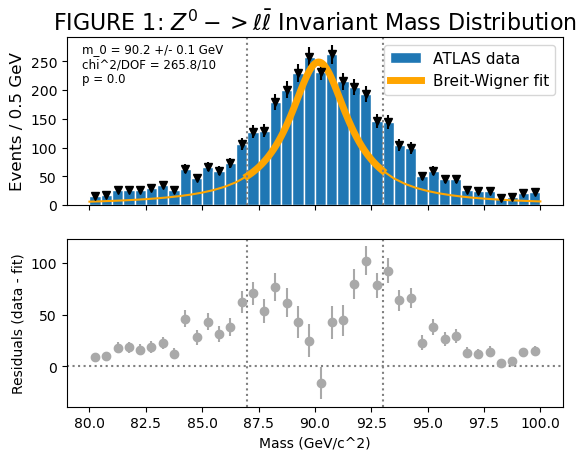

In [3]:
# step 1
def D(m, m_0, G):
    return (G / 2) / (np.pi * ((m - m_0)**2 + (G / 2)**2))
    
# step 2
masses = M(pt1, pt2, eta1, eta2, phi1, phi2, E1, E2)
mask = (centers > 87) & (centers < 93)
numbers, edges = np.histogram(masses, linspace)
bin_width = (linspace[1] - linspace[0]) / 1
normalization_factor = 2500

# we want to scale the breit wigner function by the normalization factor
# so
def normalized_D(m, m_0, G):
    return normalization_factor * bin_width * D(m, m_0, G) # 0.5 because we need to account that each bin is only half a gev

params, covar = curve_fit(normalized_D, centers[mask], numbers[mask], sigma=errors[mask], p0=[91, 2.5], absolute_sigma=True) # idk what a good initial point would be but normal gammas seem to be in the low single digits online

# step 3
fig, (ax, hatchet) = plt.subplots(2, 1, sharex=True)
ax.hist(masses, bins=linspace, edgecolor='white', label="ATLAS data") # replot
ax.errorbar(centers, numbers, yerr=errors, color='black', fmt='v')
# Unsure if the whole Breit-Wigner fit is wanted, but I've just created the fit using 87-93
smallLinspace = np.linspace(87, 93, 100)
ax.plot(smallLinspace, normalized_D(smallLinspace, *params), label="Breit-Wigner fit", linewidth=5, color='orange')
ax.plot(linspace, normalized_D(linspace, *params), color='orange')
# residual panel is differences between data and fit
hatchet.errorbar(centers, numbers - normalized_D(centers, *params), yerr=errors, fmt='o', color='darkgray')
hatchet.axhline(0, color='gray', ls=':')
# vertical lines. idk whether we want them in both or just one but here's both
ax.axvline(87, color='gray', ls=':')
ax.axvline(93, color='gray', ls=':')
hatchet.axvline(87, color='gray', ls=':')
hatchet.axvline(93, color='gray', ls=':')

hatchet.set_xlabel('Mass (GeV/c^2)')
hatchet.set_ylabel('Residuals (data - fit)')

# step 4
values = normalized_D(centers[mask], *params)
chisq = np.sum(((numbers[mask] - values) / errors[mask])**2) # errors defined in part 1
deg_freedom = mask.sum() - 2 # not three because we fixed normalization at 2500
chisq_reduced = chisq / deg_freedom
p = st.chi2.sf(chisq, deg_freedom)
# print(p)
# ...that's not a great p value.

# step 5
# the covariance matrix is weird statistics but i think (hope) this is the same thing
mass_part, gamma_part = params
error_on_the_mass = np.sqrt(covar[0,0]) # since they're along the diagonal
print(f"Best fit m_0 = {mass_part:.3f} GeV")
print(f"Uncertainty on the mass is +/- {error_on_the_mass:.3f} GeV")

# step six seven
# label things
annotation = (f"m_0 = {mass_part:.1f} +/- {error_on_the_mass:.1f} GeV\nchi^2/DOF = {chisq:.1f}/{deg_freedom}\np = {p:.1f}")
ax.text(0.03, 0.97, annotation, transform=ax.transAxes, va='top', ha='left', fontsize=8.5)

ax.set_ylabel("Events / 0.5 GeV", fontsize=12)
ax.legend(fontsize=11)
ax.set_title("FIGURE 1: $Z^0 -> \\ell\\bar{\\ell}$ Invariant Mass Distribution", fontsize=16)


## Part 3: 2D Parameter Scan
----

As emphasized in class, this is a 2D fit, and you cannot determine $Z^0$ and $\Gamma_{exp}$ independently. In this part, you visualize the joint probability space.


1. Perform a 2D chi-square scan of the mass-width parameter space. To make grading easier, please scan in  mass from 89 to 91 GeV, and the width from 5 to 8, with 300 bins along each dimension. 
2. Make a filled contour plot of the $\Delta \chi^2 = \chi^2 - \chi^2_{min}$. Clip the $\Delta \chi^2$ at 35 units to make the plot easier to see. Add a colorbar. Make the plot look nice, with appropriate labels. Note that this is a $\Delta \chi^2$ map. This means the minimum value on the z-axis should be zero.
3. Draw the $1\sigma$ and $3\sigma$ confidence levels onto the plot using a solid and dashed line, respectively.  Use the matplotlib `clabel` capability to label the levels appropriately.
   * Hint 1: If you need a refresher on how to do this, please check [this matplotlib page](https://matplotlib.org/stable/gallery/images_contours_and_fields/contour_label_demo.html)
   * Hint 2: You can look up the $\Delta \chi^2$ corresponding to the $1\sigma$ and $3\sigma$ levels online, or they can be seen in Lecture **11**. Pay close attention to how many degrees of freedom you have.
5. Draw a dot/cross at the best fit location from Part 2.
6. Label this plot clearly as **Figure 2**.




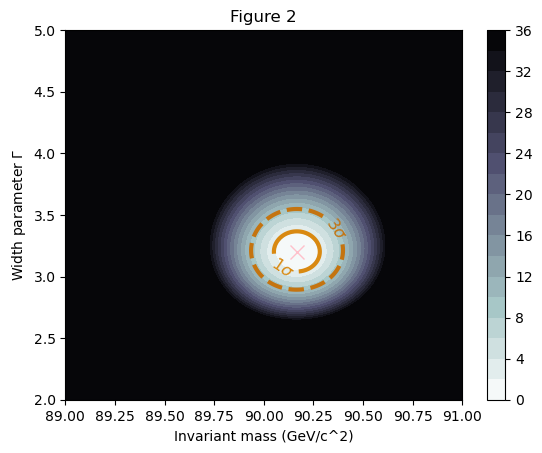

In [4]:
# step 1

# NOTE - not sure why we're having width range from 5 to 8?
# If we take g ranging from 2 to 5 instead, this actually shows the x in the middle
# of the sigma contours. which is what we want.
# I guess it's possible that I've calculated gamma wrong.
# But for now, I'm going to have the g_space range from 2 to 5
# since otherwise the plot is quite unclear.

m0_space = np.linspace(89, 91, 300)
# g_space = np.linspace(5, 8, 300)
g_space = np.linspace(2, 5, 300)
m0_grid, g_grid = np.meshgrid(m0_space, g_space)

numbers_fit = numbers[mask]
errors_fit = errors[mask]
bin_centers = centers[mask]

# there's probably a vectorizable way to iterate over the grid but this is fine
chisq_grid = np.zeros((300, 300))
for i, m0 in enumerate(m0_space):
    for j, g in enumerate(g_space):
        expected = normalized_D(bin_centers, m0_grid[i, j], g_grid[i, j])
        chisq_grid[i, j] = np.sum(((numbers_fit - expected) / errors_fit)**2)

# step 2
# two parameters (m0 and G) -> 2 dof
# "clip the delta chi squared"? Okay there's a function for this
delta_chisq = np.clip(chisq_grid - chisq_grid.min(), 0, 35)
fig, ax = plt.subplots()
contourplot = ax.contourf(m0_space, g_space, delta_chisq, levels=20, cmap='bone_r')
# looks like z minimum is already at zero which is good since i don't know how i'd reset axes
cbar = fig.colorbar(contourplot)
ax.set_xlabel("Invariant mass (GeV/c^2)")
ax.set_ylabel("Width parameter $\\Gamma$")

# step 3
# lecture 11 says 2.30 and 9.21 for 1 and 3 sigma, respectively, at 2 dof
# two contour plots because they're different line styles
sig1contour = ax.contour(m0_space, g_space, delta_chisq, levels=[2.30], colors='#D98911', linestyles='-', linewidths=3)
sig3contour = ax.contour(m0_space, g_space, delta_chisq, levels=[9.21], colors='#C47410', linestyles='--', linewidths=3)
ax.clabel(sig1contour, fmt={2.30: '1$\\sigma$'}, fontsize=12)
ax.clabel(sig3contour, fmt={9.21: '3$\\sigma$'}, fontsize=12) # from stackoverflow, not the included matplotlib page

# step 4
min_m0, min_g = params
ax.plot(min_m0, min_g, marker='x', color='pink', markersize=10, label='Best fit (m0, $\\Gamma$)')

# step 5
ax.set_title("Figure 2");

## Part 4: Discussion and Future Work
----

Add a brief comparison of your measured $Z^0$ relative to
the latest accepted values from the PDG. It should also include a summary of the approximations
you have made in doing your calculations, and future work necessary to make the calculations
more realistic. For example, your fit does not include any systematic uncertainties, or the energy
resolution of the ATLAS detector.


**Your Answer Goes in the markdown cell below:**


In [5]:
print(params)

[90.16635206  3.19798931]


## Discussion & future work
My measured $Z^{0}$ mass is the first value of params (90.166). Per the PDG, the mass of the Z boson is Z: 91.1880 +/- 0.0020. This is obviously quite a high degree of precision. While my calculated value is close enough that the reasoning of my calculations is correct, it's quite a ways from the accepted value.

Approximations I have made in these calculations that might have caused this discrepancy include:
- No accounting for detector resolution effects (found online that something about detectors systematically increases the width parameter)
- Bin width is pretty large. On a whim, I tried restarting the kernel and running everything with a smaller bin width, which increased the measured invariant mass value by about 0.6GeV. If I had to guess, this is probably the biggest contributor, although I'm not completely sure why there would be intra-bin variation.
- I also found online that the width parameter is also slightly dependent on mass. I'm not sure what this relation is, but we assumed an invariant $\Gamma$, so that might also play a role.
- With regard to "not includ[ing] systematic uncertainties", I don't know that these would move the calculated mass one way or the other? Since they're uncertainties and not biases, I think systematic uncertainties would only increase the calculated uncertainty. Perhaps I'm missing something, though!

Future work necessary to make the calculations more realistic would really just be controlling for all of the approximations and assumptions above (and, of course, the ones that I've missed). Taking into account the dependence of $\Gamma$ on the mass, shrinking the bin width (ideally making the calculation an integral, probably), making sure the detector engineering isn't imparting systematic bias.